In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [15]:
df = pd.read_csv("Task2.csv")

for col in ["request_time", "start_time", "finish_time"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df["time_to_start"] = (df["start_time"] - df["request_time"]).dt.total_seconds() / 60
df["handling_time"] = (df["finish_time"] - df["start_time"]).dt.total_seconds() / 60
df["total_resolution_time"] = (df["finish_time"] - df["request_time"]).dt.total_seconds() / 60
df["request_date"] = df["request_time"].dt.date
df["request_hour"] = df["request_time"].dt.hour
df["start_hour"] = df["start_time"].dt.hour

df.head()

,moderator,id_request,request_time,start_time,finish_time,team,time_to_start,handling_time,total_resolution_time,request_date,request_hour,start_hour
0,165,159660,2020-09-24 07:01:16,2020-10-01 16:00:31,2020-10-01 16:02:02,retail,10619.250000,1.516667,10620.766667,2020-09-24,7,16
1,178,160116,2020-09-24 22:32:15,2020-10-01 13:21:42,2020-10-01 13:21:43,retail,9529.450000,0.016667,9529.466667,2020-09-24,22,13
2,187,160178,2020-09-25 02:58:13,2020-10-02 11:37:16,2020-10-02 11:41:56,wholesale,10599.050000,4.666667,10603.716667,2020-09-25,2,11
3,178,160306,2020-09-25 09:44:12,2020-10-02 07:23:09,2020-10-02 07:25:33,retail,9938.950000,2.400000,9941.350000,2020-09-25,9,7
4,178,163042,2020-09-30 15:56:08,2020-10-02 07:37:33,2020-10-02 07:47:57,retail,2381.416667,10.400000,2391.816667,2020-09-30,15,7


Виконання handling_time ≤ 5 хв: 89.33 %
Днів зі середнім time_to_start ≤ 15 хв: 8.05 %
Виконання total_resolution_time ≤ 45 хв: 20.73 %


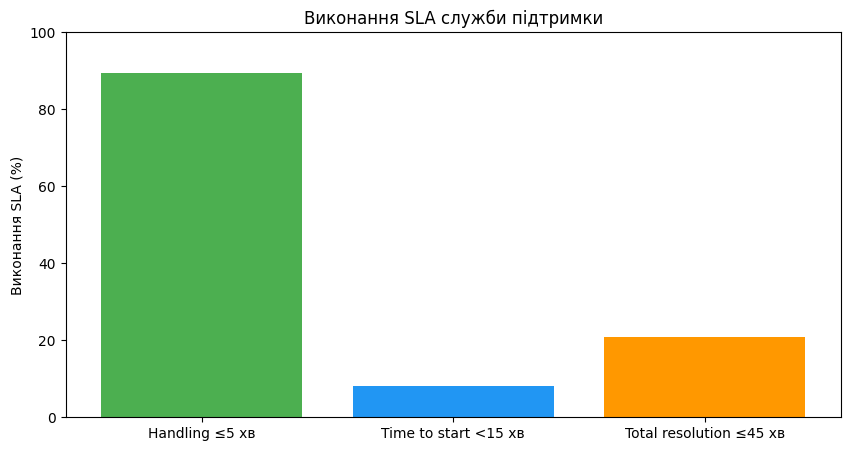

In [16]:
sla_handling = (df["handling_time"] <= 5).mean() * 100

sla_start = (df["time_to_start"] < 15).mean() * 100

sla_total = (df["total_resolution_time"] <= 45).mean() * 100

print("Виконання handling_time ≤ 5 хв:", round(sla_handling, 2), "%")
print("Днів зі середнім time_to_start ≤ 15 хв:", round(sla_start, 2), "%")
print("Виконання total_resolution_time ≤ 45 хв:", round(sla_total, 2), "%")

sla_values = [sla_handling, sla_start, sla_total]
labels = ["Handling ≤5 хв", "Time to start <15 хв", "Total resolution ≤45 хв"]

plt.figure(figsize=(10,5))
plt.bar(labels, sla_values, color=["#4CAF50", "#2196F3", "#FF9800"])
plt.ylim(0,100)
plt.ylabel("Виконання SLA (%)")
plt.title("Виконання SLA служби підтримки")
plt.show()

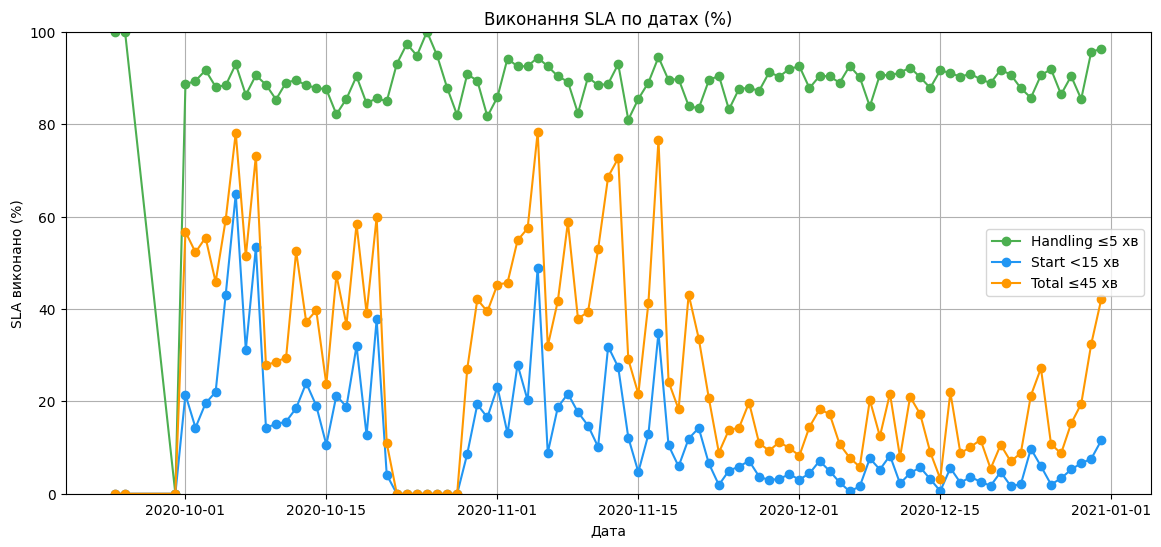

In [17]:
sla_daily = df.groupby("request_date").apply(
    lambda x: pd.Series({
        "handling_sla": (x["handling_time"] <= 5).mean() * 100,
        "start_sla": (x["time_to_start"] < 15).mean() * 100,
        "total_sla": (x["total_resolution_time"] <= 45).mean() * 100
    }),
    include_groups=False
)

plt.figure(figsize=(14,6))

plt.plot(sla_daily.index, sla_daily["handling_sla"], marker='o', label="Handling ≤5 хв", color="#4CAF50")
plt.plot(sla_daily.index, sla_daily["start_sla"], marker='o', label="Start <15 хв", color="#2196F3")
plt.plot(sla_daily.index, sla_daily["total_sla"], marker='o', label="Total ≤45 хв", color="#FF9800")

plt.ylim(0, 100)
plt.title("Виконання SLA по датах (%)")
plt.xlabel("Дата")
plt.ylabel("SLA виконано (%)")
plt.legend()
plt.grid(True)
plt.show()

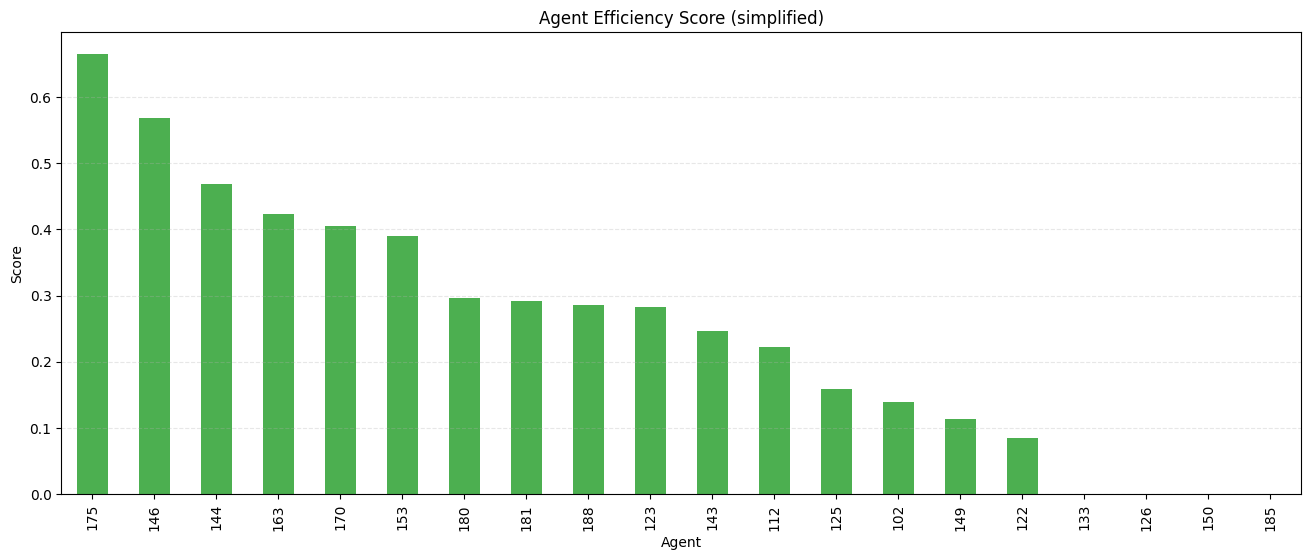

In [18]:
df["date"] = df["request_time"].dt.date

# 1. Найпростіший варіант requests per day
requests_per_day = df.groupby(["moderator", "date"])["id_request"].count().groupby("moderator").mean()

# 2. SLA агента
sla_start = df.groupby("moderator")["time_to_start"].apply(lambda x: (x < 15).mean())
sla_handling = df.groupby("moderator")["handling_time"].apply(lambda x: (x <= 5).mean())

# 3. Спрощена метрика ефективності
efficiency_score = (requests_per_day * sla_start * sla_handling).sort_values(ascending=False)

# 4. Графік
plt.figure(figsize=(16,6))
efficiency_score.tail(20).plot(kind="bar", color="#4CAF50")
plt.title("Agent Efficiency Score (simplified)")
plt.ylabel("Score")
plt.xlabel("Agent")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()

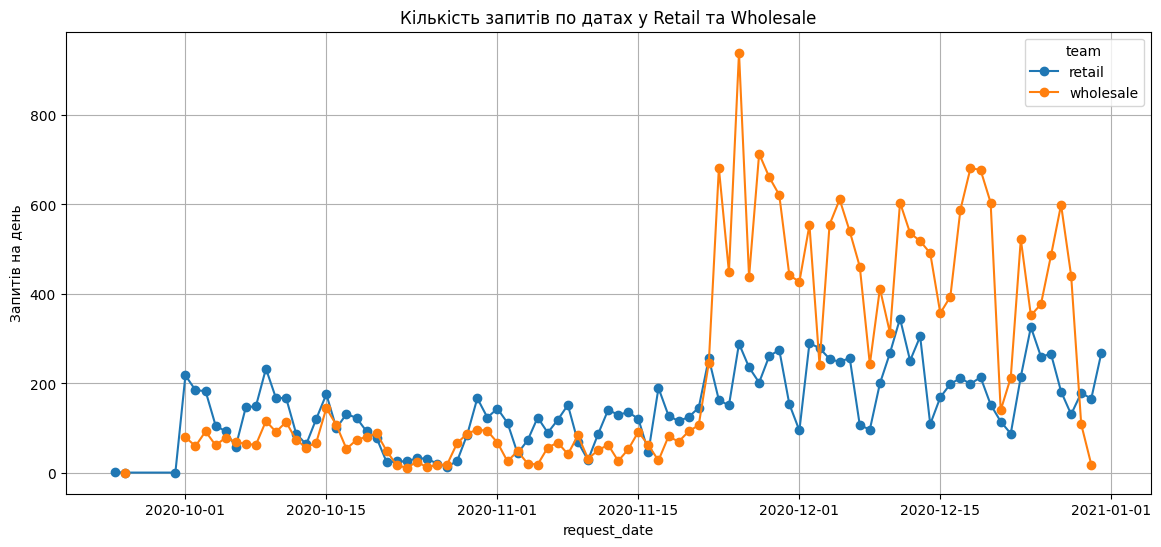


Пікове навантаження по командах:
team
retail       345
wholesale    939

Середня продуктивність агента по командах (requests/day):
team
retail       14.604370
wholesale    20.024072

Необхідна кількість агентів (розрахунок):
team
retail       23.62
wholesale    46.89

Поточна кількість агентів:
team
retail       24
wholesale    25

Додатково потрібно найняти агентів:
team
retail       -0.38
wholesale    21.89


In [19]:
requests_per_day_team = (
    df.groupby(["team", "moderator", "request_date"])["id_request"]
    .count()
    .groupby(["team", "moderator"])
    .mean()
)

requests_daily_team = df.groupby(["team", "request_date"])["id_request"].count()

requests_daily_team.unstack("team").plot(figsize=(14,6), marker="o")
plt.title("Кількість запитів по датах у Retail та Wholesale")
plt.ylabel("Запитів на день")
plt.grid(True)
plt.show()

# Максимальне навантаження у піковий день по команді
peak_load_team = requests_daily_team.groupby("team").max()

# Середня продуктивність агента у команді
avg_agent_capacity = requests_per_day_team.groupby("team").mean()

# Скільки агентів потрібно команді
agents_needed = (peak_load_team / avg_agent_capacity).round(2)

# Поточна кількість агентів
current_agents = df.groupby("team")["moderator"].nunique()

# Скільки не вистачає
additional_agents = (agents_needed - current_agents).round(2)

print("\nПікове навантаження по командах:")
print(peak_load_team.to_string())

print("\nСередня продуктивність агента по командах (requests/day):")
print(avg_agent_capacity.to_string())

print("\nНеобхідна кількість агентів (розрахунок):")
print(agents_needed.to_string())

print("\nПоточна кількість агентів:")
print(current_agents.to_string())

print("\nДодатково потрібно найняти агентів:")
print(additional_agents.to_string())

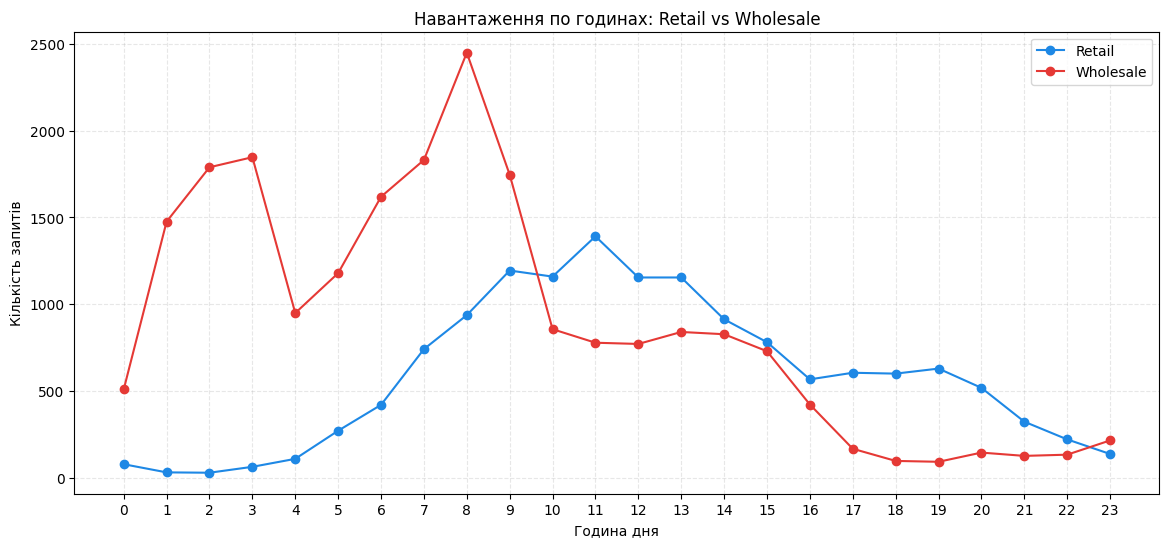

In [20]:
hourly_load = df.groupby(["team", "request_hour"])["id_request"].count().unstack("team")

plt.figure(figsize=(14,6))
plt.plot(hourly_load.index, hourly_load["retail"], marker="o", label="Retail", color="#1E88E5")
plt.plot(hourly_load.index, hourly_load["wholesale"], marker="o", label="Wholesale", color="#E53935")
plt.title("Навантаження по годинах: Retail vs Wholesale")
plt.xlabel("Година дня")
plt.ylabel("Кількість запитів")
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.xticks(range(0, 24))

plt.show()

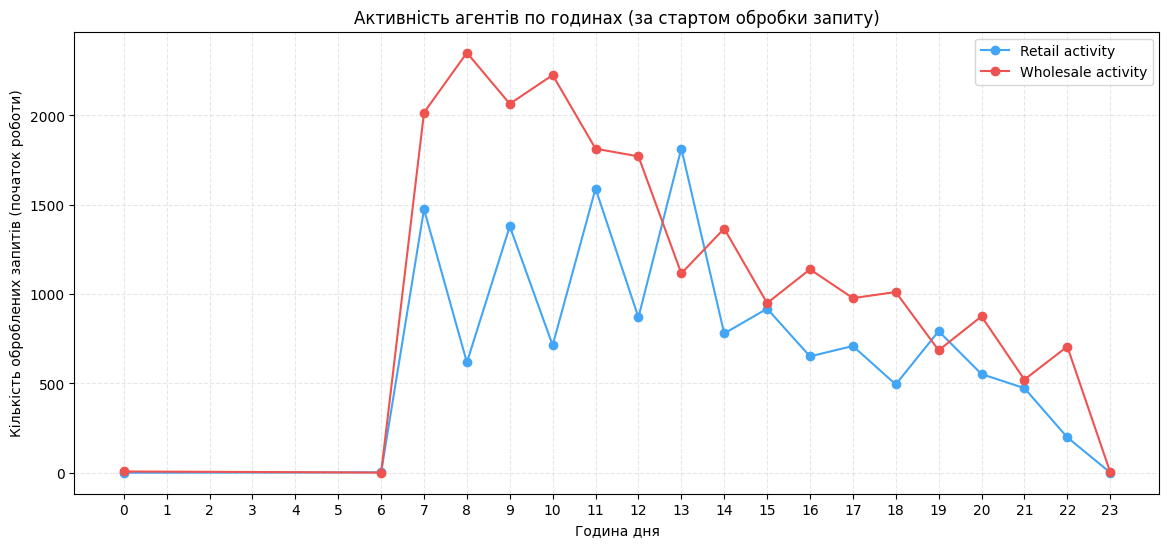

In [21]:
activity_by_hour = (
    df.groupby(["team", "start_hour"])["id_request"]
    .count()
    .unstack("team")
    .fillna(0)
)

plt.figure(figsize=(14,6))
plt.plot(activity_by_hour.index, activity_by_hour["retail"], marker="o", label="Retail activity", color="#42A5F5")
plt.plot(activity_by_hour.index, activity_by_hour["wholesale"], marker="o", label="Wholesale activity", color="#EF5350")
plt.title("Активність агентів по годинах (за стартом обробки запиту)")
plt.xlabel("Година дня")
plt.ylabel("Кількість оброблених запитів (початок роботи)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.xticks(range(0, 24))
plt.legend()
plt.show()

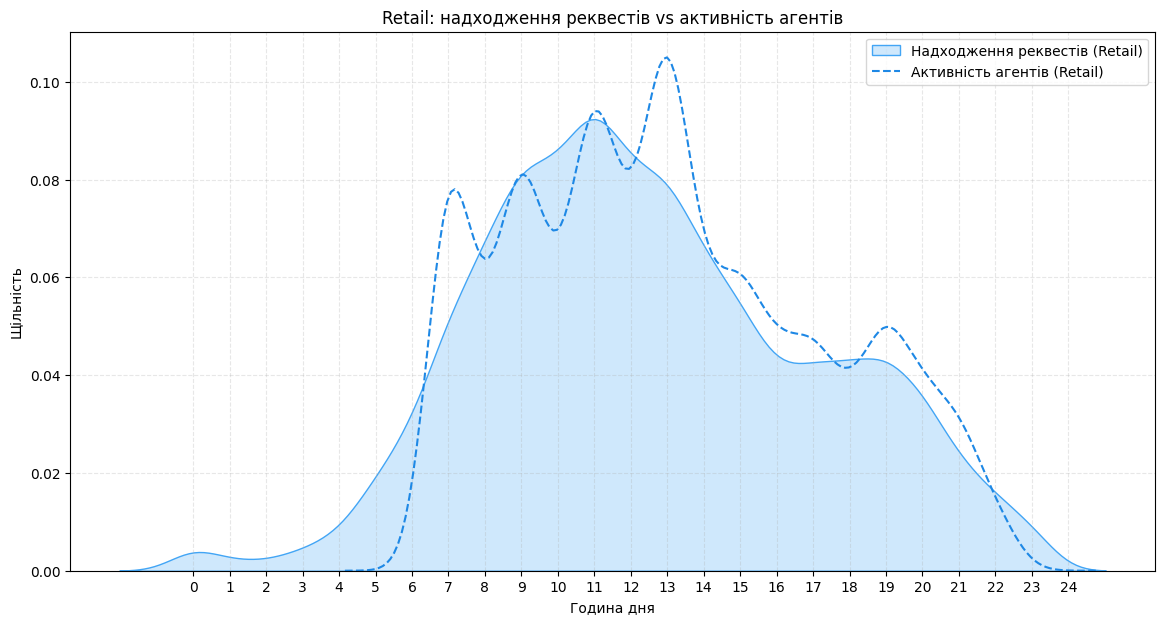

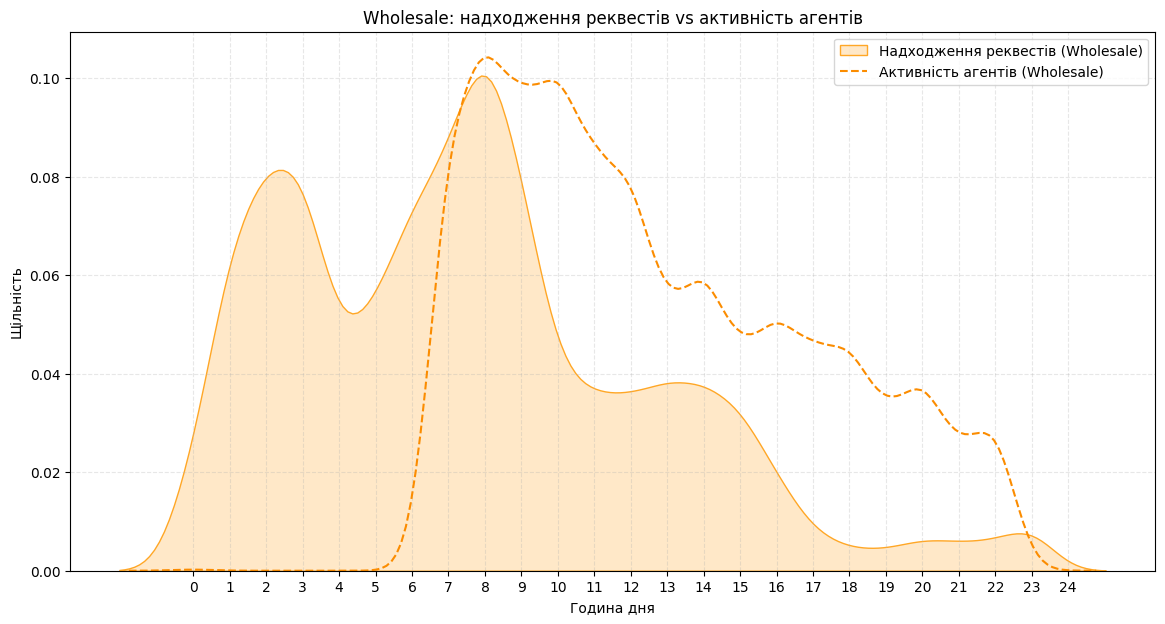

In [ ]:
retail = df[df["team"] == "retail"]
wholesale = df[df["team"] == "wholesale"]

plt.figure(figsize=(14,7))
sns.kdeplot(retail["request_hour"], fill=True, color="#42A5F5", label="Надходження реквестів (Retail)")
sns.kdeplot(retail["start_hour"], fill=False, linestyle="--", color="#1E88E5", label="Активність агентів (Retail)")
plt.title("Retail: надходження реквестів vs активність агентів")
plt.xlabel("Година дня")
plt.ylabel("Щільність")
plt.xticks(range(0, 25))
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(14,7))
sns.kdeplot(wholesale["request_hour"], fill=True, color="#FFA726", label="Надходження реквестів (Wholesale)")
sns.kdeplot(wholesale["start_hour"], fill=False, linestyle="--", color="#FB8C00", label="Активність агентів (Wholesale)")
plt.title("Wholesale: надходження реквестів vs активність агентів")
plt.xlabel("Година дня")
plt.ylabel("Щільність")
plt.xticks(range(0, 25))
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.show()
